## Phase1: Exploring the dataset
Prior to analyzing, we'll understand the structure of data , its shape , types of columns as well as if any values are missing 

In [1]:
import pandas as pd
schools=pd.read_csv("data/schools.csv")
print(schools.shape)
schools.head(20)

(375, 7)


,school_name,borough,building_code,average_math,average_reading,average_writing,percent_tested
0,"New Explorations into Science, Technology and ...",Manhattan,M022,657,601,601,NaN
1,Essex Street Academy,Manhattan,M445,395,411,387,78.9
2,Lower Manhattan Arts Academy,Manhattan,M445,418,428,415,65.1
3,High School for Dual Language and Asian Studies,Manhattan,M445,613,453,463,95.9
4,Henry Street School for International Studies,Manhattan,M056,410,406,381,59.7
5,Bard High School Early College,Manhattan,M097,634,641,639,70.8
6,Urban Assembly Academy of Government and Law,Manhattan,M445,389,395,381,80.8
7,Marta Valle High School,Manhattan,M025,438,413,394,35.6
8,University Neighborhood High School,Manhattan,M446,437,355,352,69.9
9,New Design High School,Manhattan,M445,381,396,372,73.7


In [2]:
schools.info()
schools.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   school_name      375 non-null    object 
 1   borough          375 non-null    object 
 2   building_code    375 non-null    object 
 3   average_math     375 non-null    int64  
 4   average_reading  375 non-null    int64  
 5   average_writing  375 non-null    int64  
 6   percent_tested   355 non-null    float64
dtypes: float64(1), int64(3), object(3)
memory usage: 20.6+ KB


,average_math,average_reading,average_writing,percent_tested
count,375.000000,375.000000,375.000000,355.000000
mean,432.944000,424.504000,418.458667,64.976338
std,71.952373,61.881069,64.548599,18.747634
min,317.000000,302.000000,284.000000,18.500000
25%,386.000000,386.000000,382.000000,50.950000
50%,415.000000,413.000000,403.000000,64.800000
75%,458.500000,445.000000,437.500000,79.600000
max,754.000000,697.000000,693.000000,100.000000


In [3]:
schools.isnull().sum()

school_name         0
borough             0
building_code       0
average_math        0
average_reading     0
average_writing     0
percent_tested     20
dtype: int64

**Findings**
the dataset has 375 rows and 7 columns, all columns are not null except `percent_tested` which has 20 missing values found via `df.isnull().sum()` 


## Phase 2: Handling missing values
The `percent_tested` column has 20 missing values out of 375 schools (~5.3%). Not huge yet not negligible.
**Decision:** we'll keep all 375 rows in thedataset, but filter the missing `percent_tested` rows once needed for analysis

### Total SAT score per school

In [4]:
schools["total_SAT"]=schools["average_math"]+schools["average_reading"]+schools["average_writing"]
schools.head(3)

,school_name,borough,building_code,average_math,average_reading,average_writing,percent_tested,total_SAT
0,"New Explorations into Science, Technology and ...",Manhattan,M022,657,601,601,NaN,1859
1,Essex Street Academy,Manhattan,M445,395,411,387,78.9,1193
2,Lower Manhattan Arts Academy,Manhattan,M445,418,428,415,65.1,1261


### Best math score

In [5]:
math_max=schools["average_math"].max()
schools.loc[schools["average_math"] == math_max, ["school_name","average_math"]
            ]

,school_name,average_math
88,Stuyvesant High School,754


**findings**: the school wih highest math average is `Stuyvesant High School` with an average of `754`

### Top 10 schools by total SAT

In [6]:
schools.sort_values( by="total_SAT", ascending=False).head(10)[["school_name","total_SAT"]]

,school_name,total_SAT
88,Stuyvesant High School,2144
170,Bronx High School of Science,2041
93,Staten Island Technical High School,2041
174,High School of American Studies at Lehman College,2013
333,Townsend Harris High School,1981
365,Queens High School for the Sciences at York Co...,1947
5,Bard High School Early College,1914
280,Brooklyn Technical High School,1896
45,Eleanor Roosevelt High School,1889
68,"High School for Mathematics, Science, and Engi...",1889


### Borough with the most schools in the top 10

In [7]:
top_10=schools.sort_values(by="total_SAT" , ascending=False).head(10)
top_10["borough"].value_counts()

Manhattan        4
Bronx            2
Queens           2
Staten Island    1
Brooklyn         1
Name: borough, dtype: int64

**findings**: The borough with the most schools in the top 10 by total SAT score is **Manhattan**, with **4** schools.

### Borough with the highest and lowest average total SAT

In [8]:
schools.groupby("borough")["total_SAT"].mean().sort_values(ascending=False)

borough
Staten Island    1439.000000
Queens           1345.478261
Manhattan        1340.134831
Brooklyn         1230.256881
Bronx            1202.724490
Name: total_SAT, dtype: float64

**Findings :** `Staten Island ` has the highest SAT while `Bronx` has the lowest.

### Borough summary: school count, mean, and std dev of total SAT, sorted by std dev

In [9]:
schools.groupby("borough")["total_SAT"].agg(["count", "mean", "std"]).sort_values(by="std", ascending=False)

,count,mean,std
borough,,,
Manhattan,89,1340.134831,230.294140
Staten Island,10,1439.000000,222.303596
Queens,69,1345.478261,195.252899
Brooklyn,109,1230.256881,154.868427
Bronx,98,1202.724490,150.393901


**Findings:** Manhattan is large but with contrast(highest std), while Brooklyn/Bronx are large and consistent but lower-performing, and Staten Island's numbers aren't enough for a conclusion.

### reset_index() before and after a groupby

In [10]:
schools.groupby("borough")["total_SAT"].agg(["count", "mean", "std"]).sort_values(by="std", ascending=False).reset_index()

,borough,count,mean,std
0,Manhattan,89,1340.134831,230.294140
1,Staten Island,10,1439.000000,222.303596
2,Queens,69,1345.478261,195.252899
3,Brooklyn,109,1230.256881,154.868427
4,Bronx,98,1202.724490,150.393901


## Phase 4: Going deeper and beyond

### Finding if there's a correlation between the percent of students tested and the SAT Averages 

In [11]:
# Remove rows with missing percent_tested values
schools_tested = schools.dropna(subset=["percent_tested"])

# Calculate correlation
correlation = schools_tested["percent_tested"].corr(schools_tested["total_SAT"])

correlation

0.6038737364634237

**Findings**: There's a mid-to-strong positive correlation (0.60) between `percent_tested` and `total_SAT`. Schools with higher percentage of students who take the SAT tend to have higher average scores.

### How do Performance tiers distribute across boroughs ?

In [12]:
# split schools into 4 equal groups (quartiles) based on total_SAT
schools["performance_tier"]=pd.qcut(
    schools["total_SAT"], q=4 , labels=["1st quartile-bottom 25 %", "2nd quartile", "3rd quartile" , "4th quartile-top 25 %" ]
)
cross_tab_table=pd.crosstab(
    schools["borough"],schools["performance_tier"]
)
cross_tab_table

performance_tier,1st quartile-bottom 25 %,2nd quartile,3rd quartile,4th quartile-top 25 %
borough,,,,
Bronx,35,30,27,6
Brooklyn,35,36,18,20
Manhattan,18,15,24,32
Queens,7,12,22,28
Staten Island,0,0,2,8


**Finding:** Performance tiers are not evenly spread across boroughs. Manhattan and Staten Island are toward the top tier, while Bronx is in the bottom tiers (only 6 of its 98 schools reach the top quartile). we also see Manhattan's high variability (from Q6)thanks to a cluster of top-performing schools. Staten Island's should be treated cautiously given its small sample size (only 10 schools).

### Finding outlier schools

In [13]:
# split schools into 4 equal groups based on percent_tested
schools["tested_tier"]=pd.qcut(
    schools["percent_tested"], q=4 , labels=["1st quartile-bottom 25 %", "2nd quartile", "3rd quartile" , "4th quartile-top 25 %" ]
)
#print schools with top 25% performance and bottom 25% tested percentage
print(schools.loc[
    (schools["performance_tier"] == "4th quartile-top 25 %") &
    (schools["tested_tier"] == "1st quartile-bottom 25 %"),
    ["school_name", "borough", "performance_tier", "tested_tier"]
])
#print schools with top 25% tested percentege and bottom 25% performance
print(schools.loc[
    (schools["performance_tier"] == "1st quartile-bottom 25 %") &
    (schools["tested_tier"] == "4th quartile-top 25 %"),
    ["school_name", "borough", "performance_tier", "tested_tier"]
])

                                           school_name   borough  \
218  City Polytechnic High School of Engineering, A...  Brooklyn   

          performance_tier               tested_tier  
218  4th quartile-top 25 %  1st quartile-bottom 25 %  
                                       school_name    borough  \
42                   Manhattan Bridges High School  Manhattan   
119                                    Bronx Latin      Bronx   
160                          New World High School      Bronx   
215             Brooklyn International High School   Brooklyn   
269         International High School at Lafayette   Brooklyn   
295  International High School at Prospect Heights   Brooklyn   

             performance_tier            tested_tier  
42   1st quartile-bottom 25 %  4th quartile-top 25 %  
119  1st quartile-bottom 25 %  4th quartile-top 25 %  
160  1st quartile-bottom 25 %  4th quartile-top 25 %  
215  1st quartile-bottom 25 %  4th quartile-top 25 %  
269  1st quartile-bott

**Finding:** Most schools follow the general trend (more testing and higher scores), but a few break it. Only City Polytechnic High School of Engineering has top-tier performance despite bottom-tier testing rates

Besides, six schools have a high percentage of students but still land in the bottom performance tier, and surprisingly, several of these have "International" 
in their name, whixh would mean they may have recent immigrant/ESL populations. it doesnt necessarily mean they perform weaker , but likely, because of langauage barrier .

### What is the average difference between a school's strongest subject and weakest subject For each borough

In [14]:
#calculate for each school the gap between highest average and lowesest 
schools["subject_gap"] = schools[["average_math", "average_reading", "average_writing"]].max(axis=1) - schools[["average_math", "average_reading", "average_writing"]].min(axis=1)
#find average gaps for each borough sorted out 
schools.groupby("borough")["subject_gap"].mean().sort_values(ascending=True)


borough
Staten Island    17.100000
Bronx            19.010204
Brooklyn         24.587156
Manhattan        27.764045
Queens           29.739130
Name: subject_gap, dtype: float64

**Findings**: 
as we see, `Staten Islands ` has the smallest difference, this suggests it performs similarly accross all subjects , whereas `Queens` has the highest one , so it performs on some subjects better than other 

## Phase 5: vizualisations

###  bar chart: average total_SAT by borough

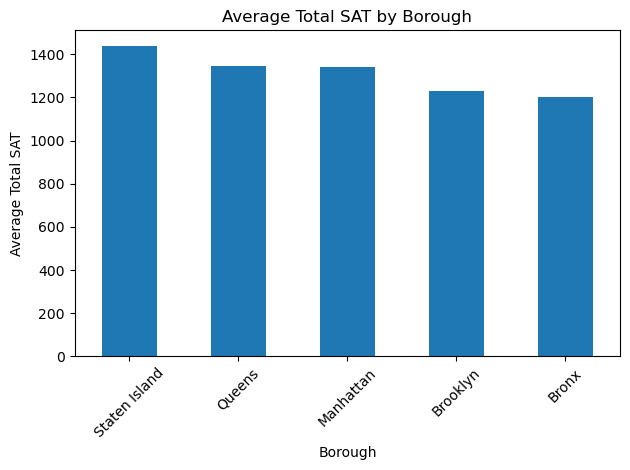

In [15]:
import matplotlib.pyplot as plt

borough_avg = schools.groupby("borough")["total_SAT"].mean().sort_values(ascending=False)
borough_avg.plot(kind="bar", title="Average Total SAT by Borough")
plt.ylabel("Average Total SAT")
plt.xlabel("Borough")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("images/borough_avg_sat.png")  
plt.show()

**Finding**:
Staten Island has the highest average total SAT (~1440), though
not accurate since its small sample size (10 schools). Queens 
and Manhattan are close behind . Brooklyn and Bronx follow
noticeably behind the other three boroughs.

### scatter plot: percent_tested vs total_SAT

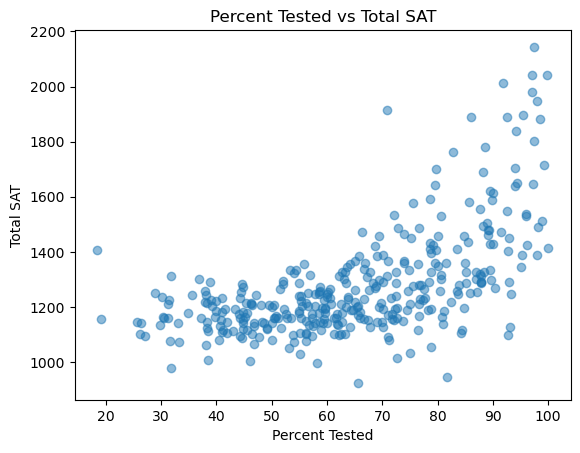

In [16]:
plt.scatter(schools_tested["percent_tested"], schools_tested["total_SAT"], alpha=0.5)
plt.xlabel("Percent Tested")
plt.ylabel("Total SAT")
plt.title("Percent Tested vs Total SAT")
plt.savefig("images/percent_tested_vs_sat.png")
plt.show()

**Findings**:
we see moderate-positive correlation  
as percent tested increases, total SAT tends to increase too, though the 
though there's some outliers. A few points break the pattern noticeably

### distribution of total_SAT

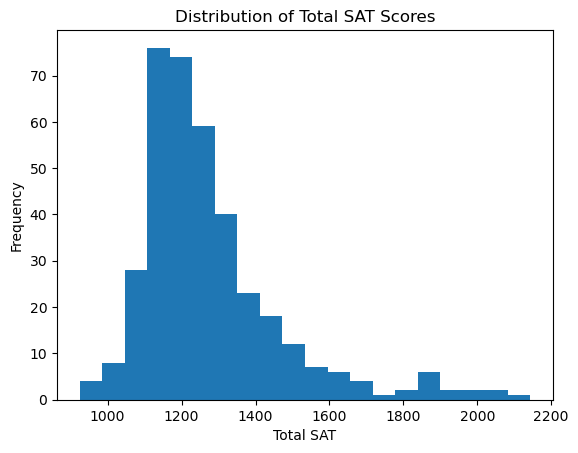

In [17]:
schools["total_SAT"].plot(kind="hist", bins=20, title="Distribution of Total SAT Scores")
plt.xlabel("Total SAT")
plt.savefig("images/sat_distribution.png")
plt.show()

**Findings**: 
Most schools score between roughly 1050 and 1350 total SAT. The distribution 
is right-skewed, with a small group of high-performing schools (1800+)